# 📊 Estatística Descritiva com Dados do Censo Escolar 2023
Este notebook realiza uma análise completa de estatística descritiva sobre dados do Censo Escolar 2023. Todos os cálculos são acompanhados de suas respectivas visualizações e seguem o padrão de estilo PEP 8 do Python

In [13]:
# 📊 Estatística Descritiva com Dados do Censo Escolar 2023
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
# Estilo
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
os.makedirs("graficos", exist_ok=True)

In [15]:
# 📥 Leitura dos dados
caminho_arquivo = r"C:/Users/Usuario/Desktop/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv"
colunas_utilizadas = [
    "NO_REGIAO", "TP_LOCALIZACAO", "TP_DEPENDENCIA", "CO_UF", "QT_MAT_BAS", "QT_TUR_BAS"
]

In [16]:
# 📥 Leitura dos dados COMPLETA
caminho_arquivo = r"C:/Users/Usuario/Desktop/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv"
colunas_utilizadas = [
    "NO_REGIAO", "TP_LOCALIZACAO", "TP_DEPENDENCIA", "CO_UF", "QT_MAT_BAS", "QT_TUR_BAS"
]
dados_df = pd.read_csv(
    caminho_arquivo,
    sep=";",
    encoding="latin1",
    usecols=colunas_utilizadas
)
dados_df.rename(columns={
    "TP_LOCALIZACAO": "localizacao",
    "TP_DEPENDENCIA": "dependencia",
    "QT_MAT_BAS": "matriculas",
    "QT_TUR_BAS": "turmas",
    "NO_REGIAO": "regiao"
}, inplace=True)

In [17]:
dados_df.rename(columns={
    "TP_LOCALIZACAO": "localizacao",
    "TP_DEPENDENCIA": "dependencia",
    "QT_MAT_BAS": "matriculas",
    "QT_TUR_BAS": "turmas",
    "NO_REGIAO": "regiao"
}, inplace=True)

In [18]:
# 🔄 Mapeamento
mapa_localizacao = {1: "Urbana", 2: "Rural"}
mapa_dependencia = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}

In [19]:
dados_df["localizacao"] = dados_df["localizacao"].map(mapa_localizacao)
dados_df["dependencia"] = dados_df["dependencia"].map(mapa_dependencia)

In [20]:
# 📊 Estatísticas agrupadas
print(dados_df.groupby("regiao")[["matriculas", "turmas"]].agg(["mean", "median", "std"]))
print(dados_df.groupby("dependencia")[["matriculas", "turmas"]].agg(["mean", "median", "std"]))

              matriculas                        turmas                  
                    mean median         std       mean median        std
regiao                                                                  
Centro-Oeste  352.391901  244.0  337.595372  15.638614   12.0  11.377618
Nordeste      228.660902  148.0  299.739994  10.628321    9.0   9.215798
Norte         216.337666  105.0  283.080471  10.058429    7.0  10.209564
Sudeste       309.956044  196.0  394.897306  14.151783   11.0  10.874295
Sul           250.785418  150.0  402.235559  13.091731   10.0  12.297308
             matriculas                        turmas                  
                   mean median         std       mean median        std
dependencia                                                            
Estadual     480.577843  384.0  456.261992  17.759862   15.0  12.777527
Federal      539.087819  455.0  436.458898  19.699717   17.0  15.723874
Municipal    218.540658  144.0  230.688252  10.628553   

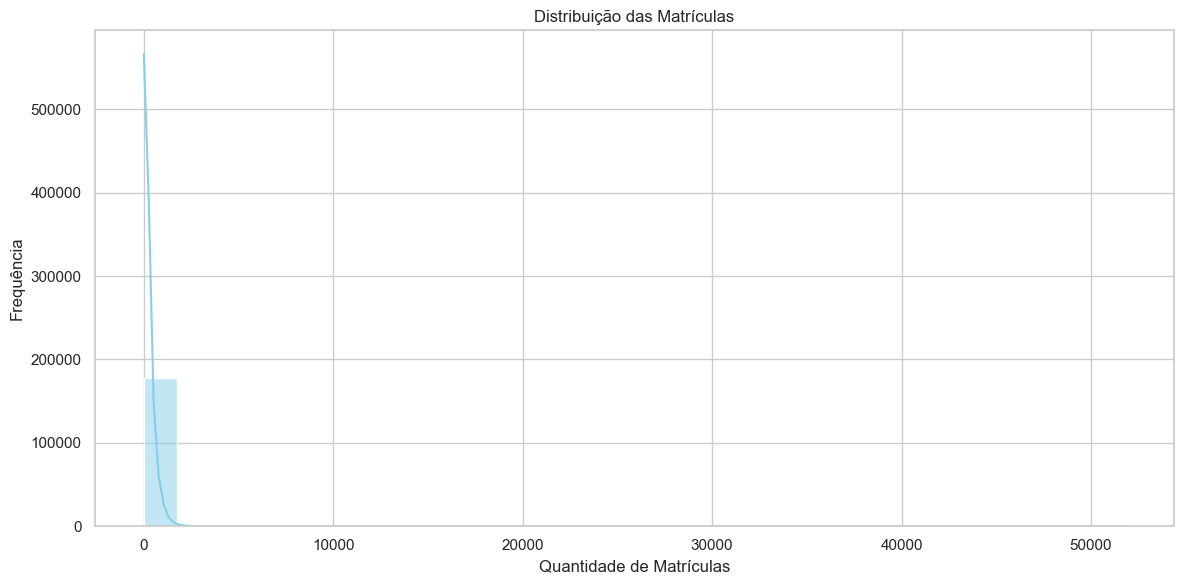

In [21]:
# 📈 Gráficos
# Histograma
plt.figure()
sns.histplot(data=dados_df, x="matriculas", bins=30, kde=True, color="skyblue")
plt.title("Distribuição das Matrículas")
plt.xlabel("Quantidade de Matrículas")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig("graficos/histograma_matriculas.png")
plt.show()

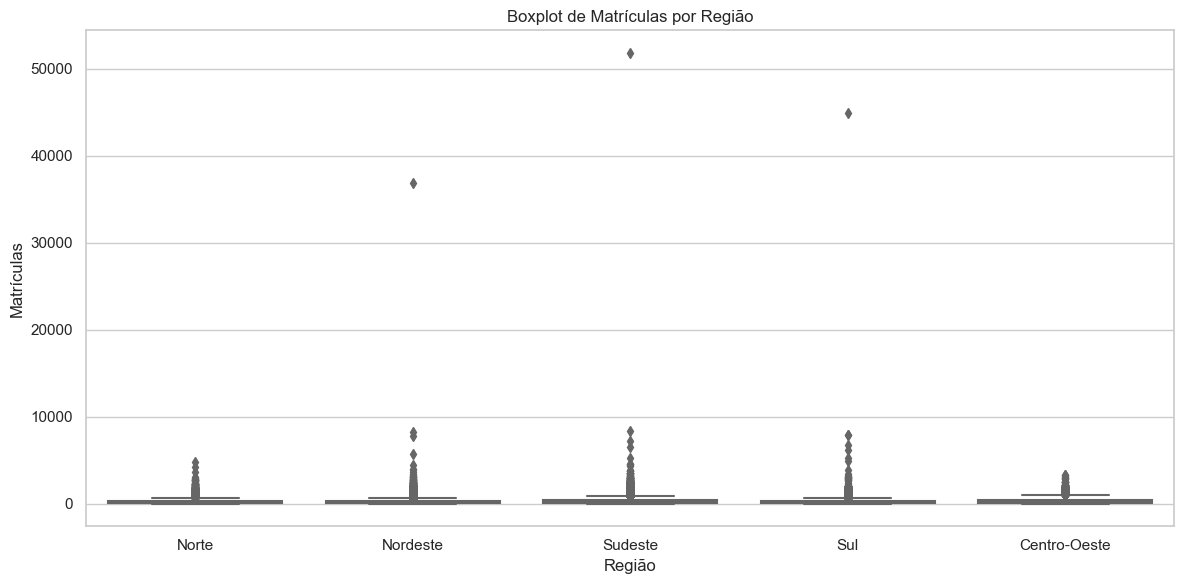

In [22]:
# Boxplot por região
plt.figure()
sns.boxplot(x="regiao", y="matriculas", data=dados_df, palette="Set3")
plt.title("Boxplot de Matrículas por Região")
plt.xlabel("Região")
plt.ylabel("Matrículas")
plt.tight_layout()
plt.savefig("graficos/boxplot_matriculas_regiao.png")
plt.show()

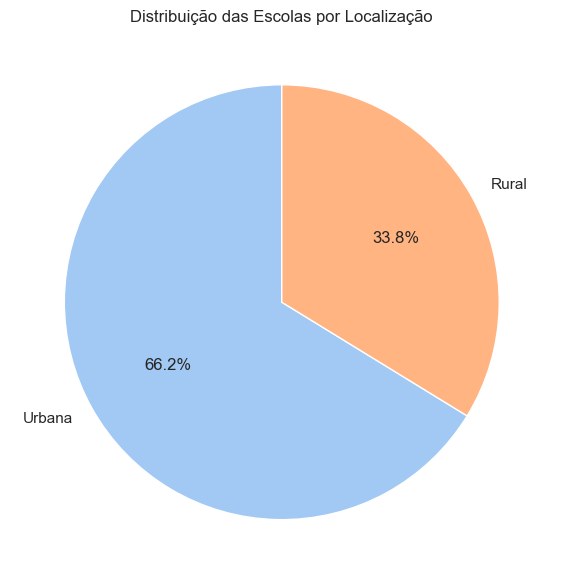

In [23]:
# Gráfico de pizza
plt.figure()
dados_df["localizacao"].value_counts().plot.pie(
    autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Distribuição das Escolas por Localização")
plt.ylabel("")
plt.tight_layout()
plt.savefig("graficos/pizza_localizacao.png")
plt.show()

In [24]:
# 📋 Tabelas resumo
print(dados_df.groupby("regiao")["matriculas"].count().to_frame("Total de Escolas"))
print(pd.crosstab(dados_df["localizacao"], dados_df["dependencia"]))

              Total de Escolas
regiao                        
Centro-Oeste             10421
Nordeste                 59850
Norte                    22078
Sudeste                  60356
Sul                      25771
dependencia  Estadual  Federal  Municipal  Privada
localizacao                                       
Rural            6960       97      65436      970
Urbana          26586      628      65273    51675
